- try to fill missing values
- apply auto-correlation
- check the model feature importances
- use the `user activity`
- apply aggregations for the warehouse
- apply moving average
- Clip the taget

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
#from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import random
from math import pi
import statsmodels.api as sm
plt.style.use('fivethirtyeight')
from statsmodels.tsa.seasonal import seasonal_decompose
class CFG:
    data_folder = '/Users/ahmed/Downloads/computerscience/AI-Compeitions/Rohlik Orders Forecasting Challenge/Data/'
    img_dim1 = 20
    img_dim2 = 10
    img_dim1 = 20
    img_dim2 = 10

#setting the metrics:

In [5]:
def reading_data(path:str):
    smaple = pd.read_csv(path+'solution_example.csv')
    train = pd.read_csv(path + "train.csv")
    test = pd.read_csv(path + "test.csv")
    test_id = test['id']  # store the 'id' column from the test dataframe
    return train, test, test_id


train, test, test_ids = reading_data(CFG.data_folder)
train_date = train['date']
test_date = test['date']

In [6]:
def get_time_features(train: pd.DataFrame, test: pd.DataFrame) -> pd.DataFrame:
    for df in (train, test):
        df['date'] = pd.to_datetime(df['date'])
        df['date_day'] = df['date'].dt.day
        df['week'] = df['date'].dt.dayofweek
        df['date_month'] = df['date'].dt.month
        df['Year'] = df['date'].dt.year
        df['friday'] = (df['date'].dt.dayofweek == 4).astype(int)
        #df['sunday'] = (df['date'].dt.dayofweek == 6).astype(int)
        #df['the_fun_2'] = df['sunday'] + df['friday']
        df['holiday_before'] = df['holiday'].shift(1).fillna(0).astype(int)
        df['holiday_after'] = df['holiday'].shift(-1).fillna(0).astype(int)
        df.drop(columns=['date','id'], inplace=True)
    return train, test

train, test = get_time_features(train=train, test=test)

# Encoding

In [7]:
def encoding(train: pd.DataFrame, test: pd.DataFrame) -> pd.DataFrame:
    train = pd.get_dummies(train, columns=['holiday_name'], drop_first=True)
    test = pd.get_dummies(test, columns=['holiday_name'], drop_first=True)

    encoder = LabelEncoder()
    cat_feats = train.select_dtypes(include='object')
    for df in (train, test):
        for col in df.columns:
            if col in cat_feats and col != 'holiday_name':
                df[col] = encoder.fit_transform(df[col])

    return train, test

train, test = encoding(train, test)


In [8]:
for col in train.columns:
    if col not in test.columns:
        if col != 'orders':
            train.drop(columns=col,axis=1, inplace=True)

# Building the CV

In [ ]:
model = LGBMRegressor(random_state = 777)
model = CatBoostRegressor(random_state = 777)
model = XGBRegressor(random_state = 777)

groups = train['warehouse']
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

def validate(trainset, testset, target_col):
    model.fit(trainset.drop(columns=target_col), trainset[target_col])
    pred = model.predict(testset.drop(columns=target_col))
    valid_idx = testset[target_col].notna()
    valid_testset = testset[target_col][valid_idx]
    valid_pred = pred[valid_idx]
    print('std:', valid_testset.std())
    score = mean_absolute_percentage_error(valid_testset, valid_pred)
    print('score :',score)
    return score
stds = []
mapes = []

for train_index , test_index in tscv.split(train.drop(columns=['orders']), train['orders'], groups=groups):
    train_v, test_v = train.iloc[train_index], train.iloc[test_index]
    stds.append(test_v['orders'])
    mapes.append(validate(train_v,test_v,'orders'))
print('mape :' ,np.array(mapes).mean())
print('mapes stds :', np.array(mapes).std())
print('stds :', stds)
print('mapes :', mapes)

Streaming output truncated to the last 5000 lines.
73:	learn: 618.3882332	total: 269ms	remaining: 3.37s
74:	learn: 616.1582290	total: 273ms	remaining: 3.37s
75:	learn: 612.6776547	total: 275ms	remaining: 3.34s
76:	learn: 610.0079851	total: 277ms	remaining: 3.32s
77:	learn: 606.8048789	total: 280ms	remaining: 3.31s
78:	learn: 604.0723911	total: 282ms	remaining: 3.29s
79:	learn: 601.5263341	total: 284ms	remaining: 3.27s
80:	learn: 600.3089130	total: 286ms	remaining: 3.25s
81:	learn: 597.2950322	total: 288ms	remaining: 3.22s
82:	learn: 595.6452831	total: 290ms	remaining: 3.21s
83:	learn: 592.7777580	total: 293ms	remaining: 3.19s
84:	learn: 589.9654836	total: 295ms	remaining: 3.18s
85:	learn: 588.3032608	total: 298ms	remaining: 3.17s
86:	learn: 585.8598165	total: 300ms	remaining: 3.15s
87:	learn: 583.9912213	total: 303ms	remaining: 3.14s
88:	learn: 579.9889377	total: 305ms	remaining: 3.12s
89:	learn: 577.0650614	total: 307ms	remaining: 3.11s
90:	learn: 575.2937977	total: 310ms	remaining: 3

In [ ]:
np.mean(mapes)

0.43570544899961644

In [9]:
# Initialize models
models = [
    ('LGBM', LGBMRegressor(random_state=777)),
    ('XGB', XGBRegressor(random_state=777))
]


groups = train['warehouse']
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

def validate_ensemble(trainset, testset, target_col, models):
    predictions = np.zeros(len(testset))

    for name, model in models:
        model.fit(trainset.drop(columns=target_col), trainset[target_col])
        pred = model.predict(testset.drop(columns=target_col))
        predictions += pred

    predictions /= len(models)  # Averaging the predictions

    valid_idx = testset[target_col].notna()
    valid_testset = testset[target_col][valid_idx]
    valid_pred = predictions[valid_idx]

    score = mean_absolute_percentage_error(valid_testset, valid_pred)
    print(f'Standard Deviation: {valid_testset.std()}')
    print(f'MAPE Score: {score}')
    return score

stds = []
mapes = []

for train_index, test_index in tscv.split(train.drop(columns=['orders']), train['orders'], groups=groups):
    train_v, test_v = train.iloc[train_index], train.iloc[test_index]
    stds.append(test_v['orders'].std())
    mapes.append(validate_ensemble(train_v, test_v, 'orders', models))

print('Mean MAPE:', np.array(mapes).mean())
print('MAPE Standard Deviation:', np.array(mapes).std())
print('Standard Deviations:', stds)
print('MAPE Scores:', mapes)

# Final model ensemble training on the entire dataset
final_predictions = np.zeros(len(test))

for name, model in models:
    model.fit(train.drop(columns='orders'), train['orders'])
    final_predictions += model.predict(test)

final_predictions /= len(models)  # Averaging the predictions

# Overfitting check: Evaluate training performance
def check_overfitting(trainset, target_col, models):
    train_preds = np.zeros(len(trainset))

    for name, model in models:
        train_preds += model.predict(trainset.drop(columns=target_col))

    train_preds /= len(models)
    train_score = mean_absolute_percentage_error(trainset[target_col], train_preds)
    print(f'Training MAPE Score: {train_score}')

    return train_score

check_overfitting(train, 'orders', models)

/Users/ahmed/Downloads/computerscience/AI-Compeitions/Rohlik Orders Forecasting Challenge/venv-geoai-ground-level-no2-estimation/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1213: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000208 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 72
[LightGBM] [Info] Number of data points in the train set: 1225, number of used features: 11
[LightGBM] [Info] Start training from score 8476.468571
Standard Deviation: 1129.7141856748206
MAPE Score: 0.16985018063370053
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 73
[LightGBM] [Info] Number of data points in the train set: 2448, number of used features: 11
[LightGBM] [I

np.float64(0.029482174336238752)

In [ ]:
# Create submission file
sub_df = pd.DataFrame({'id': test_ids, 'orders': final_predictions})
#sub_df.to_csv('submission0023586495157734453ensemble.csv', index=False)

In [15]:
#0.017691843344090918
# Define base models
def get_base_models(seed):
    return [
        ('LGBM', LGBMRegressor(random_state=seed)),
        ('XGB', XGBRegressor(random_state=seed)),
        ('RF', RandomForestRegressor(random_state=seed))
    ]

# Define a meta-model for stacking
meta_model = RandomForestRegressor()

# Define seeds for stability
seeds = [42, 123, 777, 999, 2023]

groups = train['warehouse']
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

def stacking_ensemble(trainset, testset, target_col, models, meta_model):
    # Create arrays to hold the predictions from each base model
    base_train_preds = np.zeros((len(trainset), len(models)))
    base_test_preds = np.zeros((len(testset), len(models)))

    # Train each base model and get predictions
    for i, (name, model) in enumerate(models):
        model.fit(trainset.drop(columns=target_col), trainset[target_col])
        base_train_preds[:, i] = model.predict(trainset.drop(columns=target_col))
        base_test_preds[:, i] = model.predict(testset.drop(columns=target_col))

    # Train the meta-model using base model predictions as features
    meta_model.fit(base_train_preds, trainset[target_col])

    # Predict with the meta-model
    final_predictions = meta_model.predict(base_test_preds)

    # Validate predictions
    valid_idx = testset[target_col].notna()
    valid_testset = testset[target_col][valid_idx]
    valid_pred = final_predictions[valid_idx]

    score = mean_absolute_percentage_error(valid_testset, valid_pred)
    print(f'MAPE Score: {score}')
    return score

stds = []
mapes = []

# Ensemble over different seeds
for seed in seeds:
    models = get_base_models(seed)
    print(f'\nProcessing Seed: {seed}\n')

    for train_index, test_index in tscv.split(train.drop(columns=['orders']), train['orders'], groups=groups):
        train_v, test_v = train.iloc[train_index], train.iloc[test_index]
        stds.append(test_v['orders'].std())
        mapes.append(stacking_ensemble(train_v, test_v, 'orders', models, meta_model))

print('Mean MAPE:', np.array(mapes).mean())
print('MAPE Standard Deviation:', np.array(mapes).std())
print('Standard Deviations:', stds)
print('MAPE Scores:', mapes)

# Final stacking model training on the entire dataset with different seeds
final_predictions = np.zeros(len(test))

for seed in seeds:
    models = get_base_models(seed)
    base_test_preds = np.zeros((len(test), len(models)))

    for i, (name, model) in enumerate(models):
        model.fit(train.drop(columns='orders'), train['orders'])
        base_test_preds[:, i] = model.predict(test)

    final_predictions += meta_model.predict(base_test_preds)

final_predictions /= len(seeds)  # Averaging predictions across seeds

# Overfitting check: Evaluate training performance
# Overfitting check: Evaluate training performance
def check_overfitting(trainset, target_col, models, meta_model):
    base_train_preds = np.zeros((len(trainset), len(models)))

    for i, (name, model) in enumerate(models):
        # Fit the model before prediction
        model.fit(trainset.drop(columns=target_col), trainset[target_col])
        base_train_preds[:, i] = model.predict(trainset.drop(columns=target_col))

    train_preds = meta_model.predict(base_train_preds)
    train_score = mean_absolute_percentage_error(trainset[target_col], train_preds)
    print(f'Training MAPE Score: {train_score}')

    return train_score


check_overfitting(train, 'orders', get_base_models(seeds[-1]), meta_model)


Processing Seed: 42

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 72
[LightGBM] [Info] Number of data points in the train set: 1225, number of used features: 11
[LightGBM] [Info] Start training from score 8476.468571


/Users/ahmed/Downloads/computerscience/AI-Compeitions/Rohlik Orders Forecasting Challenge/venv-geoai-ground-level-no2-estimation/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1213: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


MAPE Score: 0.1738022761911778
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 73
[LightGBM] [Info] Number of data points in the train set: 2448, number of used features: 11
[LightGBM] [Info] Start training from score 7816.458333
MAPE Score: 0.33018907114118595
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 3671, number of used features: 11
[LightGBM] [Info] Sta

/Users/ahmed/Downloads/computerscience/AI-Compeitions/Rohlik Orders Forecasting Challenge/venv-geoai-ground-level-no2-estimation/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1213: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


MAPE Score: 0.17331278082784993
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 73
[LightGBM] [Info] Number of data points in the train set: 2448, number of used features: 11
[LightGBM] [Info] Start training from score 7816.458333
MAPE Score: 0.32684222351181547
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000180 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 3671, number of used features: 11
[LightGBM] [Info] St

...

/Users/ahmed/Downloads/computerscience/AI-Compeitions/Rohlik Orders Forecasting Challenge/venv-geoai-ground-level-no2-estimation/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1213: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


MAPE Score: 0.17379396699206986
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 73
[LightGBM] [Info] Number of data points in the train set: 2448, number of used features: 11
[LightGBM] [Info] Start training from score 7816.458333
MAPE Score: 0.3277444924623044
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 3671, number of used features: 11
[LightGBM] [Info] Sta

/Users/ahmed/Downloads/computerscience/AI-Compeitions/Rohlik Orders Forecasting Challenge/venv-geoai-ground-level-no2-estimation/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1213: UserWarning: The groups parameter is ignored by TimeSeriesSplit
  warnings.warn(


MAPE Score: 0.1735801938358009
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003988 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 73
[LightGBM] [Info] Number of data points in the train set: 2448, number of used features: 11
[LightGBM] [Info] Start training from score 7816.458333
MAPE Score: 0.32583233554293495
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003493 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 3671, number of used features: 11
[LightGBM] [Info] Sta

np.float64(0.01264056621764986)

In [ ]:
for df in (train,test):
    for col in ['holiday_name_Memorial Day for the Victims of the Holocaust',
        'holiday_name_Labour Day', 'sunday', 'holiday_name_Easter Monday',
        'holiday_name_Good Friday']:
        df.drop(columns=[col], inplace=True)

In [18]:
def get_base_models(seed):
    return [
        ('LGBM', LGBMRegressor(random_state=seed)),
        ('XGB', XGBRegressor(random_state=seed)),
        ('RF', RandomForestRegressor(random_state=seed))
    ]

# Seeds for stability
seeds = [42, 123, 777, 999, 2023]

# Time series split
groups = train['warehouse']
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

# Define a function to run stacking ensemble and store predictions
def stacking_ensemble_and_store(train, test, target_col, meta_model, seeds):
    final_predictions = np.zeros(len(test))
    
    for seed in seeds:
        models = get_base_models(seed)
        base_test_preds = np.zeros((len(test), len(models)))

        for i, (name, model) in enumerate(models):
            model.fit(train.drop(columns=target_col), train[target_col])
            base_test_preds[:, i] = model.predict(test.drop(columns=target_col))

        # Meta-model training on base model predictions
        meta_model.fit(base_test_preds, train[target_col])
        final_predictions += meta_model.predict(base_test_preds)

    final_predictions /= len(seeds)  # Averaging predictions across seeds

    # Save the final predictions
    submission = pd.DataFrame({
        'Id': test.index,
        'Orders': final_predictions
    })

    submission.to_csv('stacking_ensemble_predictions.csv', index=False)
    print('Predictions saved to stacking_ensemble_predictions.csv')

    return final_predictions

# Check for overfitting on the entire training set
def check_overfitting(trainset, target_col, models, meta_model):
    base_train_preds = np.zeros((len(trainset), len(models)))

    for i, (name, model) in enumerate(models):
        model.fit(trainset.drop(columns=target_col), trainset[target_col])
        base_train_preds[:, i] = model.predict(trainset.drop(columns=target_col))

    train_preds = meta_model.predict(base_train_preds)
    train_score = mean_absolute_percentage_error(trainset[target_col], train_preds)
    print(f'Training MAPE Score: {train_score}')

    return train_score

# Final stacking model training on the entire dataset with different seeds and save predictions
meta_model = RandomForestRegressor()
final_predictions = stacking_ensemble_and_store(train, test, 'orders', meta_model, seeds)

# Check overfitting
check_overfitting(train, 'orders', get_base_models(seeds[-1]), meta_model)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 7340, number of used features: 12
[LightGBM] [Info] Start training from score 5535.443869


KeyError: "['orders'] not found in axis"

In [ ]:
#0.4578672537754837 in leaderboard 0.0774
#0.4568272951153025 in leaderboard 0.0685
#0.4492822482665694 in leaderboard 0.0453
#0.029482174336238752
#CAT = 0.43570544899961644
#XGB =

In [21]:
meta_model.fit(train.drop(columns='orders'),train['orders'])
y_predict = model.predict(test)
sub_df = pd.DataFrame({'id': test_ids,'orders':y_predict})
sub_df.to_csv('/Users/ahmed/Downloads/computerscience/AI-Compeitions/Rohlik Orders Forecasting Challenge/submiession/submission03102701344512426.csv', index=False)

In [ ]:
train_cols = set(train.columns)
test_cols = set(test.columns)
diff = train_cols.symmetric_difference(test_cols)

print("\nDifference between columns:")
print(diff)

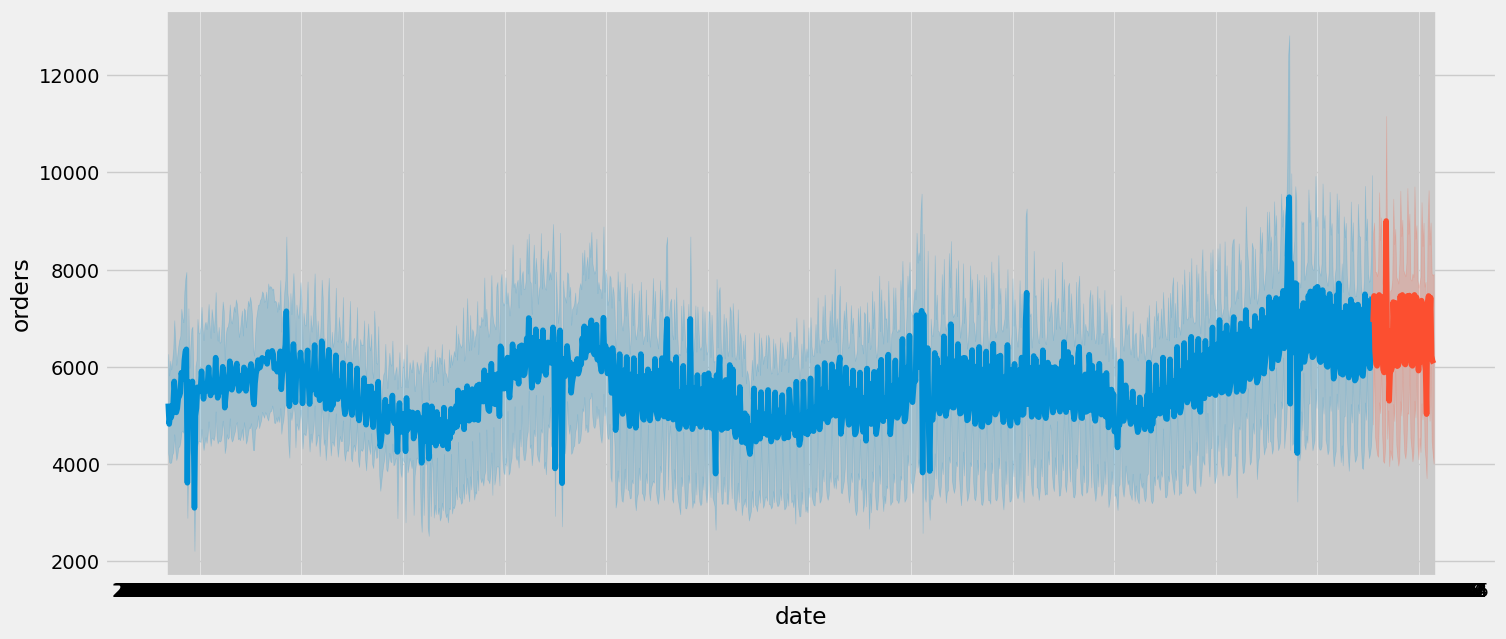

In [22]:
plt.figure(figsize=(16 , 7))
sns.lineplot(x=train_date, y=train.orders)
sns.lineplot(x=test_date, y= y_predict)
plt.show()

In [ ]:
importances = model.feature_importances_

feature_names = train.drop(columns='orders').columns
indices = np.argsort(importances)[::-1]

feature_names = feature_names[indices]
importances = importances[indices]

plt.figure(figsize=(10, 6))
plt.title("Feature importances")
plt.barh(range(len(feature_names)), importances, align="center")
plt.yticks(range(len(feature_names)), feature_names)
plt.xlabel("Importance")
plt.show()

In [ ]:
feature_names

In [ ]:
importances

In [ ]:
train.columns

#check the dates of the test and the train
#the publich leaderboard is not 30% first of the data and not the last 30% of the data.
#read the book and finish the course
#try the same methods here in the foreast one you build.